# Блок 7. Основы искусственного интеллекта и машинного обучения
## Занятие 7. Деревья решений (Decision Tree)

### Что такое дерево решений

Дерево решений — один из самых понятных алгоритмов машинного обучения.

Алгоритм задаёт последовательность вопросов:

- Доход больше 50 000?
- Возраст больше 30?
- Есть кредит?

И постепенно приходит к решению.

### Преимущества

- легко объяснять;
- легко визуализировать;
- подходит для бизнеса;
- показывает важность признаков.

### Недостатки

- может переобучаться;
- чувствителен к шуму.

### Новые понятия

- узел (node);
- лист (leaf);
- глубина дерева (max_depth);
- переобучение.

### Связь с дипломом

Деревья решений часто используют:

- HR;
- банки;
- недвижимость;
- продажи;
- медицину.


Сначала изучите SOLVED-ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. Загрузка датасета

### Алгоритм
Используем Breast Cancer.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

url = "../../data/daily_meal_table.csv"
df: pd.DataFrame = pd.read_csv(url)

feature_cols = ['protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g',
                'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g', ]
target_col = "is_main_meal"

df[target_col] = (df["meal"] != "breakfast").astype("int8")

print(df.shape)

assert target_col in df.columns
assert len(df) > 1000
assert df.shape[1] == 16

(15322, 16)


## Ячейка 2. Изучение данных

### Алгоритм
Смотрим признаки.

In [6]:
X = pd.DataFrame(df, columns=feature_cols)
y = pd.Series(df[target_col])
display(X.head())

print(feature_cols)

assert X.shape[1] == 10

,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
0,16.39,17.35,102.97,9.4,28.38,2.796,16.0,954.0,165.0,50.60
1,33.00,10.00,85.40,8.2,0.00,0.555,0.0,248.0,739.0,164.80
2,15.73,10.53,22.27,1.9,3.85,1.780,28.0,536.0,128.0,84.00
3,17.68,50.74,110.79,8.2,2.00,8.091,20.0,1600.0,563.0,115.20
4,16.27,6.06,92.61,7.3,2.79,1.040,12.0,512.0,614.0,182.47


['protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g', 'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g']


## Ячейка 3. Train/Test Split

### Алгоритм
Разделяем данные.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

assert len(X_train) > len(X_test)

## Ячейка 4. Первое дерево решений

### Алгоритм
Обучаем DecisionTreeClassifier.

In [8]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

assert tree is not None

## Ячейка 5. Предсказания

### Алгоритм
Получаем прогноз.

In [9]:
pred = tree.predict(X_test)
print(pred[:10])
assert len(pred) == len(y_test)

[0 1 1 0 0 1 1 1 1 0]


## Ячейка 6. Метрики качества

### Алгоритм
Считаем Accuracy.

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy", accuracy)

assert accuracy > 0.8

Accuracy 0.8453507340946166


## Ячейка 7. Глубина дерева

### Алгоритм
Изучаем сложность модели.

In [17]:
depth = tree.get_depth()
leaves = tree.get_n_leaves()

print("Depth", depth)
print("Leaves", leaves)

assert depth > 0

Depth 34
Leaves 1188


## Ячейка 8. Важность признаков

### Алгоритм
Находим самые важные признаки.

,feature,importance
5,saturated_fat_g,0.300928
0,protein_g,0.136986
4,sugars_g,0.129202
9,water_g,0.115034
1,fat_g,0.073345
7,sodium_mg,0.066981
6,cholesterol_mg,0.062226
8,potassium_mg,0.052507
3,fiber_g,0.031692
2,carbohydrates_g,0.031099


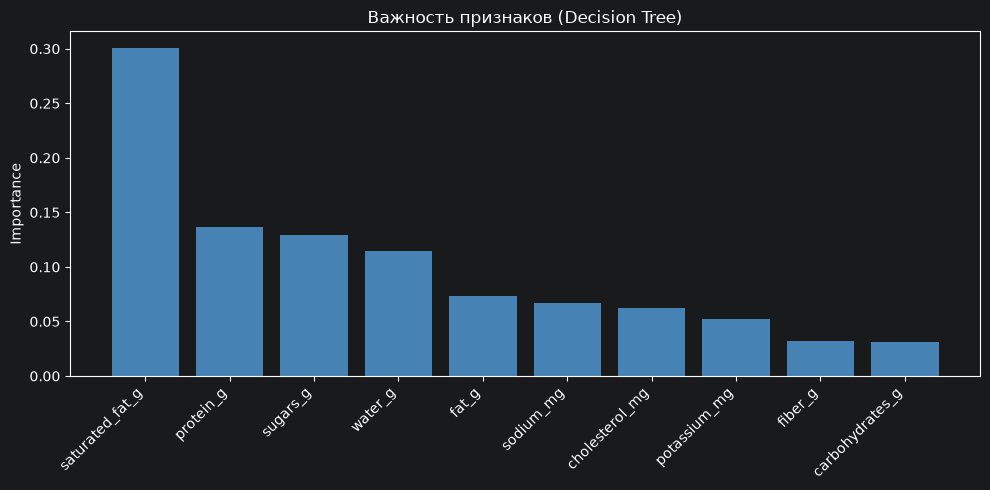

In [35]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree.feature_importances_
})

importance = importance.sort_values(by="importance", ascending=False)

display(importance)

assert len(importance) > 0

plt.figure(figsize=(10, 5))
plt.bar(importance["feature"], importance["importance"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Важность признаков (Decision Tree)")
plt.tight_layout()
plt.show()

## Ячейка 9. Борьба с переобучением

### Алгоритм
Ограничиваем глубину дерева.

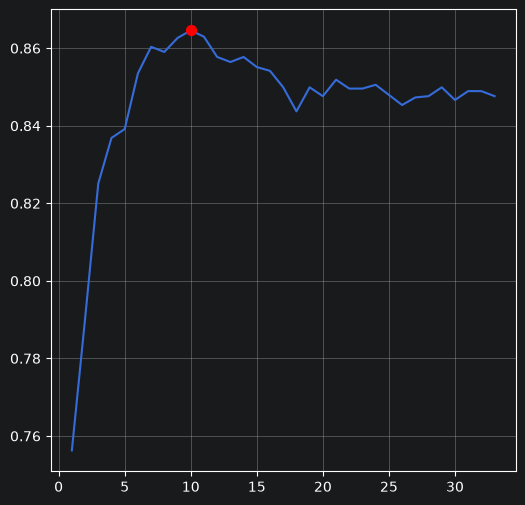

Full tree 0.8453507340946166
Best tree depth=10 with accuracy=0.8646003262642741


In [34]:
import numpy as np


depth_comp = {"depth": [], "accuracy": []}

for t_depth in range(1, depth):
    small_tree = DecisionTreeClassifier(
        max_depth=t_depth,
        random_state=42
    )
    small_tree.fit(X_train, y_train)

    small_pred = small_tree.predict(X_test)

    small_accuracy = accuracy_score(y_test, small_pred)
    depth_comp["depth"].append(t_depth)
    depth_comp["accuracy"].append(small_accuracy)

plt.figure(figsize=(6, 6))
plt.plot(depth_comp["depth"], depth_comp["accuracy"])
plt.grid(True)


best_idx   = int(np.argmax(depth_comp["accuracy"]))
best_depth = depth_comp["depth"][best_idx]
best_acc   = depth_comp["accuracy"][best_idx]

plt.scatter(
    best_depth, best_acc,
    color="red", s=50, zorder=5,
    label=f"max = {best_acc:.4f} (depth={best_depth})",
)
plt.show()

print("Full tree", accuracy)
print(f"Best tree depth={best_depth} with accuracy={best_acc}")

assert small_accuracy > 0.8

## Ячейка 10. Мини-проект

### Алгоритм
Формируем отчет.

In [22]:
report = {
    "rows": len(X),
    "features": X.shape[1],
    "accuracy": round(accuracy, 3),
    "depth": depth,
    "best_feature": importance.iloc[0]["feature"]
}

print(report)

assert report["features"] == 10

{'rows': 15322, 'features': 10, 'accuracy': 0.845, 'depth': 34, 'best_feature': 'saturated_fat_g'}
